# 📊 Gráficos Estatísticos

Ao final, você deve conseguir:

* Escolher o gráfico certo para cada tipo de análise
* Construir gráficos em Python
* Interpretar padrões, outliers e distribuições
* Usar gráficos para gerar insight (não só “mostrar dados”)

# 🧠 Começando pela dor real

O famoso artigo explora como é possível criar conjuntos de dados visualmente distintos que compartilham as mesmas estatísticas descritivas principais. Demonstra visualmente a importância da análise gráfica como complemento à análise estatística. Essa abordagem inspirou pesquisadores e praticantes a considerar a visualização como uma ferramenta essencial para evitar conclusões errôneas em análises baseadas apenas em estatísticas descritivas.


MATEJKA, Justin; FITZMAURICE, George. Same stats, different graphs: generating datasets with varied appearance and identical statistics through simulated annealing. In: Proceedings of the 2017 CHI conference on human factors in computing systems. 2017. p. 1290-1294.


**Exemplo:**

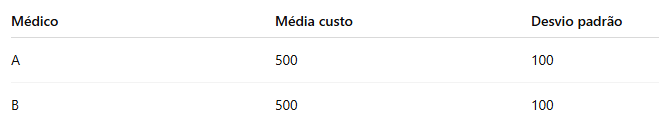

À princípio tudo igual. Mas o comportamento pode ser completamente diferente.
Mesmas estatísticas podem gerar gráficos totalmente diferentes

👉 Conclusão direta: sem gráfico, você pode tomar decisão errada

# 📊 Dataset base (saúde)

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "paciente_id": range(1, 500),
    "grupo": np.random.choice(["Baixa espera", "Alta espera"], 499),
})

# gerar custo diferente por grupo
df["custo"] = np.where(
    df["grupo"] == "Alta espera",
    np.random.gamma(2.5, 600, 499),  # mais caro e mais variável
    np.random.gamma(2, 400, 499)     # mais controlado
)

In [ ]:
df.head(3)

,paciente_id,grupo,custo
0,1,Baixa espera,2266.939336
1,2,Alta espera,923.817376
2,3,Baixa espera,1018.578332


# 📈 Histograma

👉 O histograma responde:
* Onde os dados se concentram?
* Existe assimetria?
* Existem múltiplos grupos (multimodal)?

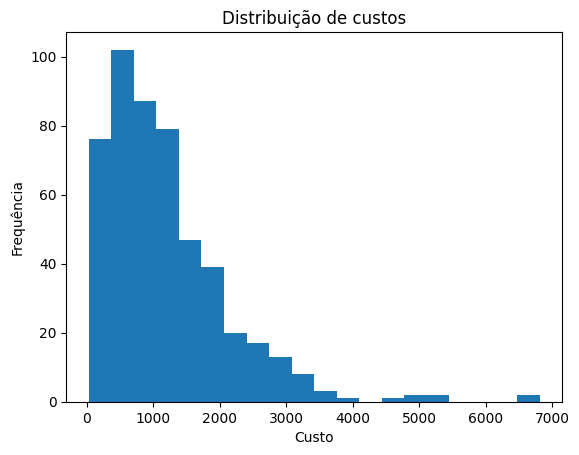

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["custo"], bins=20)
plt.title("Distribuição de custos")
plt.xlabel("Custo")
plt.ylabel("Frequência")
plt.show()

* eixo X = intervalos (bins)
* eixo Y = frequência

🧠 Interpretação: Se você vê:
* Cauda longa à direita → poucos pacientes muito caros
* Pico central → padrão dominante
* Dois picos → possíveis perfis distintos



🏥 Aplicação real. Isso aqui resolve problema de gestão:
* Identificar pacientes de alto custo
* Detectar subgrupos (ex: crônicos vs agudos)
* Avaliar impacto de intervenção

##### **Comparação com curva normal**

In [ ]:
from scipy.stats import norm

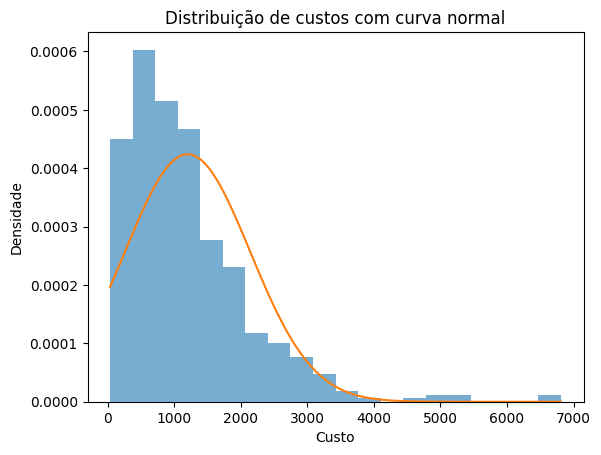

In [ ]:
# dados
dados = df["custo"]

# histograma NORMALIZADO (importante!)
plt.hist(dados, bins=20, density=True, alpha=0.6)

# calcular média e desvio padrão
media = dados.mean()
desvio = dados.std()

# gerar curva normal
x = np.linspace(dados.min(), dados.max(), 100)
y = norm.pdf(x, media, desvio)

# plotar curva
plt.plot(x, y)

plt.title("Distribuição de custos com curva normal")
plt.xlabel("Custo")
plt.ylabel("Densidade")
plt.show()

##### **Comparação entre grupos**

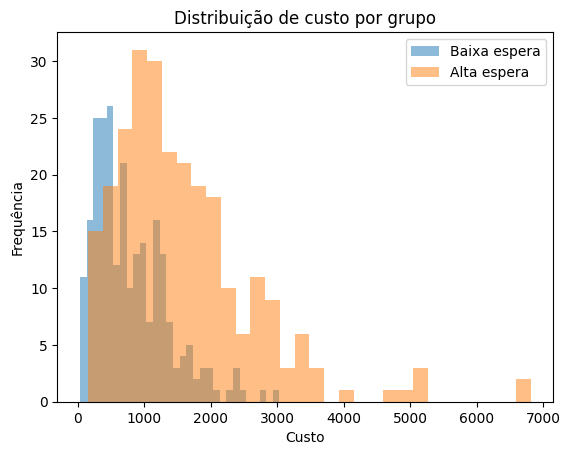

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for grupo in df["grupo"].unique():
    subset = df[df["grupo"] == grupo]
    plt.hist(subset["custo"], bins=30, alpha=0.5, label=grupo)

plt.legend()
plt.title("Distribuição de custo por grupo")
plt.xlabel("Custo")
plt.ylabel("Frequência")
plt.show()

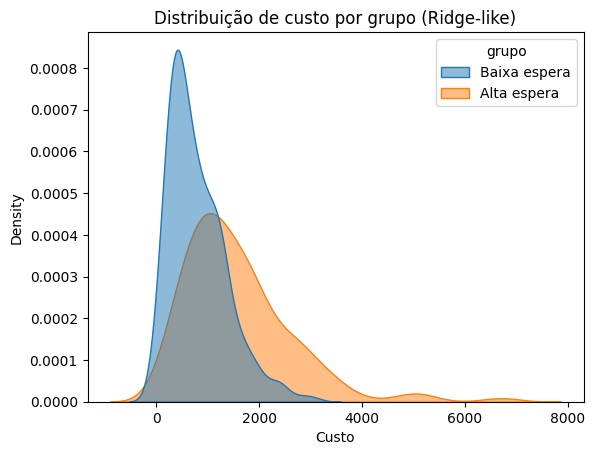

In [ ]:
import seaborn as sns

plt.figure()

sns.kdeplot(
    data=df,
    x="custo",
    hue="grupo",
    fill=True,
    common_norm=False,
    alpha=0.5
)

plt.title("Distribuição de custo por grupo (Ridge-like)")
plt.xlabel("Custo")
plt.show()

In [ ]:
!pip install joypy --quiet

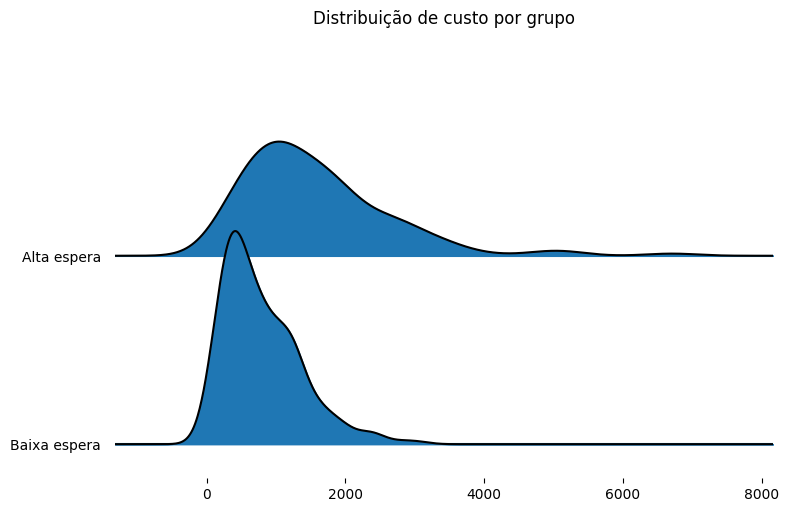

In [ ]:
import joypy

joypy.joyplot(
    df,
    by="grupo",
    column="custo",
    figsize=(8,5)
)
plt.title("Distribuição de custo por grupo")
plt.show()

# 📦 Boxplot


👉 O boxplot responde:
* Qual o intervalo central dos dados?
* Existem outliers?
* Qual grupo é mais variável?

➡️ Estrutura:
* Q1, mediana, Q3
* whiskers: bigodes
* outliers (1.5 × IQR)

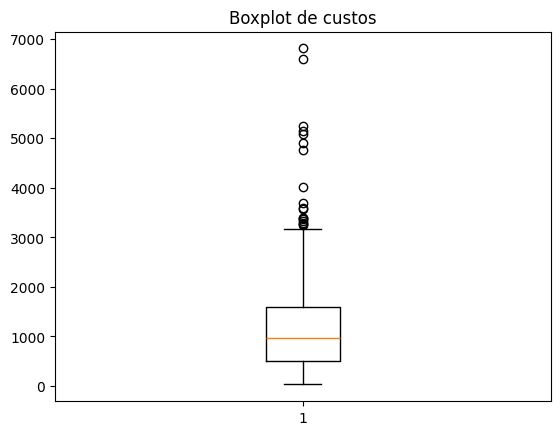

In [ ]:
plt.boxplot(df["custo"])
plt.title("Boxplot de custos")
plt.show()

🧠 Interpretação
* Caixa grande → alta variabilidade
* Linha da mediana deslocada → assimetria
* Muitos pontos fora → presença de outliers

🏥 Aplicação real: Isso aqui é muito forte:
* Detectar pacientes fora do padrão
* Avaliar variabilidade entre médicos
* Identificar problemas de protocolo

##### **Comparação entre grupos**

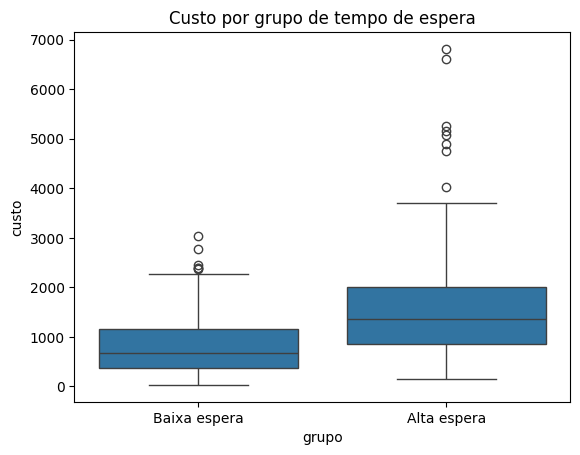

In [ ]:
import seaborn as sns

sns.boxplot(x="grupo", y="custo", data=df)
plt.title("Custo por grupo de tempo de espera")
plt.show()

#🏆 O melhor dos dois mundos

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

In [ ]:
def histograma_boxplot_plotly(
    df: pd.DataFrame,
    col_valor: str,
    titulo: str | None = None,
    rotulo_x: str | None = None,
    unidade_prefixo: str = "",
    unidade_sufixo: str = "",
    usar_log: bool = False,
    incluir_zeros: bool = True,
    remover_negativos: bool = False,
    nbins: int | None = None,
    metodo_bins: str = "sturges",  # sturges, sqrt, fd
    mostrar_curva_normal: bool = True,
    mostrar_media: bool = True,
    mostrar_mediana: bool = True,
    mostrar_boxplot: bool = True,
    mostrar_outliers_boxplot: bool = True,
    largura_px: int = 1200,
    altura_px: int = 800,
    cor_barras: str = "rgba(30, 90, 160, 0.85)",
    cor_box: str = "rgba(30, 90, 160, 0.55)",
    cor_linha_box: str = "rgba(30, 90, 160, 1.0)",
    cor_curva_normal: str = "red",
    cor_media: str = "black",
    cor_mediana: str = "green",
    exibir_figura: bool = True,
):
    """
    Gera histograma + boxplot horizontal com estatísticas descritivas.

    Parâmetros principais
    ---------------------
    df : DataFrame
        Base com a variável numérica.
    col_valor : str
        Nome da coluna numérica.
    titulo : str, opcional
        Título do gráfico.
    rotulo_x : str, opcional
        Nome do eixo X.
    unidade_prefixo / unidade_sufixo : str
        Ex.: prefixo='R$ ' ou sufixo=' min'
    usar_log : bool
        Usa escala log no eixo X.
    incluir_zeros : bool
        Se False, remove valores iguais a zero.
    remover_negativos : bool
        Se True, remove valores negativos.
    nbins : int, opcional
        Número fixo de bins. Se None, calcula automaticamente.
    metodo_bins : str
        Método para definir bins automáticos: sturges, sqrt, fd.
    """

    # =========================
    # 1) Validação e preparação
    # =========================
    if col_valor not in df.columns:
        raise ValueError(f"A coluna '{col_valor}' não existe no DataFrame.")

    serie = pd.to_numeric(df[col_valor], errors="coerce").dropna().astype(float)

    if not incluir_zeros:
        serie = serie[serie != 0]

    if remover_negativos:
        serie = serie[serie >= 0]

    if usar_log:
        serie = serie[serie > 0]

    if serie.empty:
        raise ValueError("Após os filtros aplicados, não restaram valores válidos.")

    total = int(len(serie))
    titulo = titulo or f"Distribuição de {col_valor}"
    rotulo_x = rotulo_x or col_valor

    # =========================
    # 2) Formatação numérica
    # =========================
    def fmt_num(v: float, casas: int = 2) -> str:
        s = f"{v:,.{casas}f}"
        s = s.replace(",", "X").replace(".", ",").replace("X", ".")
        return f"{unidade_prefixo}{s}{unidade_sufixo}"

    # =========================
    # 3) Número de bins
    # =========================
    if nbins is None:
        if metodo_bins.lower() == "sturges":
            nbins = int(np.ceil(1 + np.log2(total)))
        elif metodo_bins.lower() == "sqrt":
            nbins = int(np.ceil(np.sqrt(total)))
        elif metodo_bins.lower() == "fd":
            q1, q3 = np.percentile(serie, [25, 75])
            iqr_tmp = q3 - q1
            if iqr_tmp == 0:
                nbins = int(np.ceil(1 + np.log2(total)))
            else:
                bin_width = 2 * iqr_tmp / (total ** (1 / 3))
                if bin_width <= 0:
                    nbins = int(np.ceil(1 + np.log2(total)))
                else:
                    nbins = int(np.ceil((serie.max() - serie.min()) / bin_width))
        else:
            raise ValueError("metodo_bins deve ser 'sturges', 'sqrt' ou 'fd'.")

        nbins = max(5, nbins)
    else:
        nbins = int(max(1, nbins))

    # =========================
    # 4) Estatísticas
    # =========================
    media = float(serie.mean())
    mediana = float(serie.median())
    minimo = float(serie.min())
    maximo = float(serie.max())
    sd = float(serie.std(ddof=0))

    q1, q3 = np.percentile(serie, [25, 75])
    iqr = q3 - q1
    fence_low = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    n_out_low = int((serie < fence_low).sum())
    n_out_high = int((serie > fence_high).sum())

    curtose = float(pd.Series(serie).kurt())
    assimetria = float(pd.Series(serie).skew())

    # =========================
    # 5) Histograma
    # =========================
    counts, edges = np.histogram(serie, bins=nbins)
    bin_w = np.diff(edges)
    bin_c = (edges[:-1] + edges[1:]) / 2
    perc = counts / total * 100

    textos = [f"{c:,.0f} ({p:.1f}%)".replace(",", ".") for c, p in zip(counts, perc)]

    # curva normal escalada ao histograma
    x_vals = np.linspace(serie.min(), serie.max(), 400)
    sd_eff = sd if sd > 0 else 1e-9
    y_vals = stats.norm.pdf(x_vals, media, sd_eff) * total * bin_w.mean()

    # =========================
    # 6) Estrutura da figura
    # =========================
    if mostrar_boxplot:
        fig = make_subplots(
            rows=2,
            cols=1,
            shared_xaxes=True,
            row_heights=[0.75, 0.25],
            vertical_spacing=0.05,
        )
        row_hist = 1
        row_box = 2
    else:
        fig = make_subplots(rows=1, cols=1)
        row_hist = 1
        row_box = None

    # Histograma
    fig.add_trace(
        go.Bar(
            x=bin_c,
            y=counts,
            width=bin_w,
            text=textos,
            textposition="outside",
            marker=dict(color=cor_barras),
            name="Histograma",
        ),
        row=row_hist,
        col=1,
    )

    # Curva normal
    if mostrar_curva_normal:
        fig.add_trace(
            go.Scatter(
                x=x_vals,
                y=y_vals,
                mode="lines",
                line=dict(color=cor_curva_normal),
                name="Curva normal",
            ),
            row=row_hist,
            col=1,
        )

    ymax_ref = max(np.max(counts), np.max(y_vals) if mostrar_curva_normal else np.max(counts))

    # Média
    if mostrar_media:
        fig.add_trace(
            go.Scatter(
                x=[media, media],
                y=[0, ymax_ref],
                mode="lines",
                line=dict(color=cor_media, dash="dash"),
                name=f"Média: {fmt_num(media)}",
            ),
            row=row_hist,
            col=1,
        )

    # Mediana
    if mostrar_mediana:
        fig.add_trace(
            go.Scatter(
                x=[mediana, mediana],
                y=[0, ymax_ref],
                mode="lines",
                line=dict(color=cor_mediana, dash="dash"),
                name=f"Mediana: {fmt_num(mediana)}",
            ),
            row=row_hist,
            col=1,
        )

    # Boxplot
    if mostrar_boxplot and row_box is not None:
        fig.add_trace(
            go.Box(
                x=serie,
                orientation="h",
                name="Boxplot",
                boxpoints="outliers" if mostrar_outliers_boxplot else False,
                marker=dict(color=cor_box),
                line=dict(color=cor_linha_box),
            ),
            row=row_box,
            col=1,
        )

    # =========================
    # 7) Legenda expandida
    # =========================
    legenda_info = [
        f"Mínimo: {fmt_num(minimo)}",
        f"Máximo: {fmt_num(maximo)}",
        f"Amplitude: {fmt_num(maximo - minimo)}",
        f"Q1: {fmt_num(q1)}",
        f"Q3: {fmt_num(q3)}",
        f"IQR: {fmt_num(iqr)}",
        f"Outliers abaixo: {n_out_low}",
        f"Outliers acima: {n_out_high}",
        f"Assimetria: {assimetria:.2f}".replace(".", ","),
        f"Curtose: {curtose:.2f}".replace(".", ","),
    ]

    for txt in legenda_info:
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                marker=dict(color="rgba(0,0,0,0)"),
                showlegend=True,
                name=txt,
            ),
            row=row_hist,
            col=1,
        )

    # =========================
    # 8) Layout
    # =========================
    subtitulo = f"n={total:,}".replace(",", ".")
    subtitulo += f" | bins={nbins}"
    subtitulo += " | com zeros" if incluir_zeros else " | sem zeros"
    subtitulo += " | log" if usar_log else " | linear"

    fig.update_layout(
        title=dict(
            text=f"{titulo}<br><span style='font-size:12px;color:gray'>{subtitulo}</span>",
            x=0.5,
            font=dict(size=20),
        ),
        paper_bgcolor="white",
        plot_bgcolor="white",
        width=largura_px,
        height=altura_px,
        bargap=0.1,
        legend=dict(
            x=0.82,
            y=0.98,
            bgcolor="rgba(255,255,255,0.88)",
            bordercolor="rgba(0,0,0,0.1)",
            borderwidth=1,
        ),
    )

    fig.update_yaxes(title_text="Número de registros", row=row_hist, col=1)

    if mostrar_boxplot and row_box is not None:
        fig.update_yaxes(title_text="Boxplot", showgrid=False, row=row_box, col=1)
        fig.update_xaxes(title_text=rotulo_x, row=row_box, col=1)
    else:
        fig.update_xaxes(title_text=rotulo_x, row=row_hist, col=1)

    if usar_log:
        fig.update_xaxes(type="log", row=row_hist, col=1)
        if mostrar_boxplot and row_box is not None:
            fig.update_xaxes(type="log", row=row_box, col=1)

    if exibir_figura:
        fig.show()

    return fig, {
        "n": total,
        "media": media,
        "mediana": mediana,
        "minimo": minimo,
        "maximo": maximo,
        "amplitude": maximo - minimo,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "desvio_padrao": sd,
        "assimetria": assimetria,
        "curtose": curtose,
        "outliers_abaixo": n_out_low,
        "outliers_acima": n_out_high,
        "nbins": nbins,
    }

In [ ]:
df.columns

Index(['paciente_id', 'grupo', 'custo'], dtype='object')

In [ ]:
df.head(3)

,paciente_id,grupo,custo
0,1,Baixa espera,2266.939336
1,2,Alta espera,923.817376
2,3,Baixa espera,1018.578332


In [ ]:
fig, stats_dict = histograma_boxplot_plotly(
    df=df,
    col_valor="custo",
    titulo="Distribuição do sinistro por beneficiário",
    rotulo_x="Sinistro total por beneficiário",
    unidade_prefixo="R$ ",
    usar_log=False,
    incluir_zeros=False,
)